In [13]:
import zipfile

zip_path = '../datasets/HCS.zip'
parsed_tags = []

with zipfile.ZipFile(zip_path, 'r') as archive:
  with archive.open('data/training_tags.txt') as file:
    for line in file:
      line_str = line.decode('utf-8').strip()
      if not line_str:
        continue

      parts = line_str.split()
      filename_tag = parts[0]  # e.g., "001_0_1_white.png"
      move_label = parts[1]  # e.g., "d4"

      # Remove extension and split into exact tokens
      base_name = filename_tag.replace(".png", "")
      tokens = base_name.split("_")

      if len(tokens) == 4:
        game_num, page_num, move_num, color = tokens
        parsed_tags.append({
            "game": game_num,
            "page": page_num,
            "move": move_num,
            "color": color,
            "label": move_label,
            "filename": f"data/{filename_tag}",
        })

print(f"Parsed {len(parsed_tags)} tags.")
print(f"First 2 records: {parsed_tags[:3]}")



Parsed 13810 tags.
First 2 records: [{'game': '001', 'page': '0', 'move': '1', 'color': 'white', 'label': 'd4', 'filename': 'data/001_0_1_white.png'}, {'game': '001', 'page': '0', 'move': '1', 'color': 'black', 'label': 'Nf6', 'filename': 'data/001_0_1_black.png'}, {'game': '001', 'page': '0', 'move': '2', 'color': 'white', 'label': 'c4', 'filename': 'data/001_0_2_white.png'}]


In [14]:
import pandas as pd
from sqlalchemy import create_engine

df_batch = pd.DataFrame(parsed_tags)
df_batch.head()

,game,page,move,color,label,filename
0,001,0,1,white,d4,data/001_0_1_white.png
1,001,0,1,black,Nf6,data/001_0_1_black.png
2,001,0,2,white,c4,data/001_0_2_white.png
3,001,0,2,black,e6,data/001_0_2_black.png
4,001,0,3,white,Nc3,data/001_0_3_white.png


In [15]:
import os
from dotenv import load_dotenv


load_dotenv()

username = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
database = os.getenv("DB_NAME")
connection_string = (
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)
engine = create_engine(connection_string)

In [16]:
df_batch.to_sql(
    "RawScoresheetBoxes",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=500,
)

13810

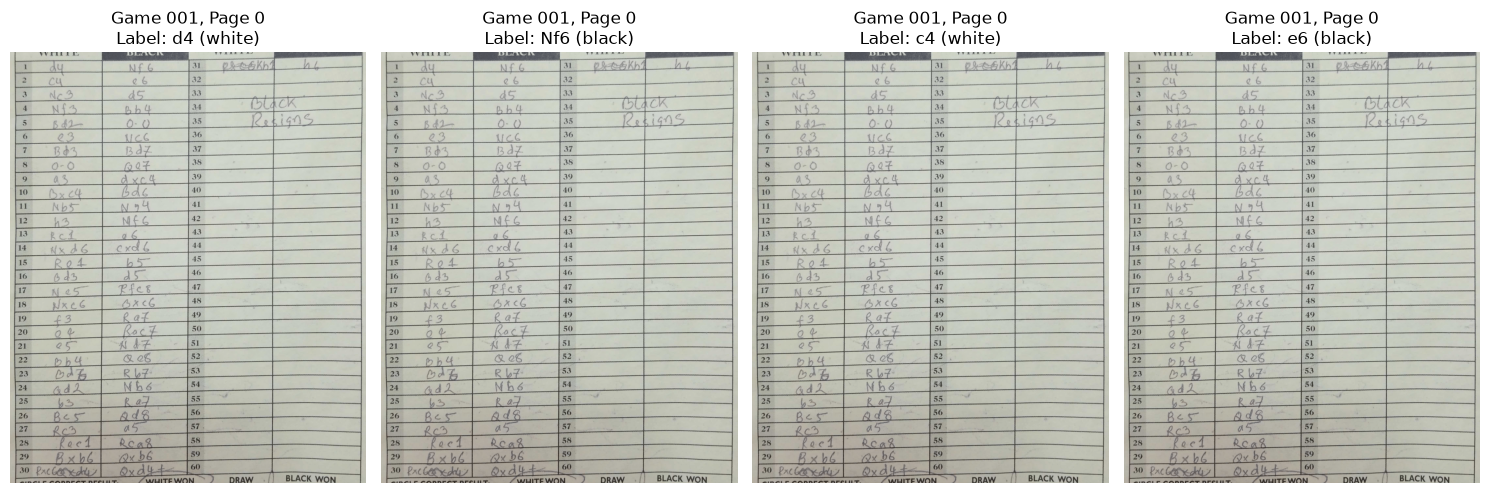

In [21]:
import zipfile
import io
from PIL import Image
import matplotlib.pyplot as plt

zip_path = '../datasets/HCS.zip'

# Grab a small batch to test
sample_df = df_batch.head(4)

fig, axes = plt.subplots(1, 4, figsize=(15, 5))

with zipfile.ZipFile(zip_path, 'r') as archive:
    for idx, row in enumerate(sample_df.iterrows()):
        row_data = row[1]
        
        # Build the correct page filename inside the zip (e.g., data/001_0.png)
        game_id = str(row_data['game']).zfill(3)  # ensures '1' becomes '001'
        page_id = row_data['page']
        zip_filename = f"data/{game_id}_{page_id}.png"
        
        true_label = row_data['label']
        color = row_data['color']
        
        # 1. Read the page image bytes directly from the zip archive
        with archive.open(zip_filename) as img_file:
            img_bytes = img_file.read()
            
        # 2. Convert bytes into a PIL image
        image_stream = io.BytesIO(img_bytes)
        pil_img = Image.open(image_stream).convert('RGB')
        
        # 3. Plot the full page (or we can crop it next based on bounding box coordinates if you have them)
        axes[idx].imshow(pil_img)
        axes[idx].set_title(f"Game {game_id}, Page {page_id}\nLabel: {true_label} ({color})")
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

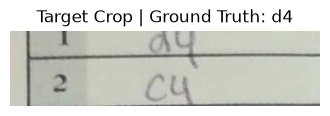

In [ ]:
zip_path = '../datasets/HCS.zip'
sample_df = df_batch.head(1)
row_data = sample_df.iloc[0]
game_id = str(row_data['game']).zfill(3)
page_id = row_data['page']
zip_filename = f'data/{game_id}_{page_id}.png'

with zipfile.ZipFile(zip_path, 'r') as archive:
  with archive.open(zip_filename) as img_file:
    full_img = Image.open(io.BytesIO(img_file.read())).convert('RGB')

width, height = full_img.size
# Rough crop for the top row
crop_box = (0, int(height * 0.03), int(width * 0.25), int(height * 0.08))
cropped_img = full_img.crop(crop_box)

plt.figure(figsize=(4, 2))
plt.imshow(cropped_img)
plt.title(
    f'Target Crop | Ground Truth: {row_data["label"]}'
)  # Fixed string formatting syntax
plt.axis('off')
plt.show()

In [ ]:
import base64
from dotenv import load_dotenv
from openai import OpenAI

# 1. Load credentials
load_dotenv(dotenv_path="../.env", override=True)
gemini_key = os.getenv("GEMINI_API_KEY")

client = OpenAI(
    api_key=gemini_key, base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
)


def transcribe_move_crop(pil_img):
  buffered = io.BytesIO()
  pil_img.save(buffered, format="PNG")
  img_base64 = base64.b64encode(buffered.getvalue()).decode("utf-8")

  response = client.chat.completions.create(
      model="gemini-3.6-flash",
      messages=[
          {
              "role": "user",
              "content": [
                  {
                      "type": "image_url",
                      "image_url": {
                          "url": f"data:image/png;base64,{img_base64}"
                      },
                  },
                  {
                      "type": "text",
                      "text": (
                          "Read the handwritten chess move written here. Output"
                          " only the text (e.g. d4)."
                      ),
                  },
              ],
          },
      ],
      max_tokens=10,
  )

  message_content = response.choices[0].message.content
  if message_content is None:
    return "BLANK_RESPONSE"
  return message_content.strip()


# 2. Load the page image from zip
zip_path = "../datasets/HCS.zip"
sample_df = df_batch.head(1)
row_data = sample_df.iloc[0]
game_id = str(row_data["game"]).zfill(3)
page_id = row_data["page"]
zip_filename = f"data/{game_id}_{page_id}.png"
true_label = row_data["label"]

with zipfile.ZipFile(zip_path, "r") as archive:
  with archive.open(zip_filename) as img_file:
    full_img = Image.open(io.BytesIO(img_file.read())).convert("RGB")

width, height = full_img.size

# 3. Tight crop strictly around Row 1 ('d4')
# Adjusting vertical bounds so it doesn't bleed into row 2
crop_box = (
    int(width * 0.08),
    int(height * 0.03),
    int(width * 0.22),
    int(height * 0.065),
)
cropped_img = full_img.crop(crop_box)

# 4. Get prediction via Gemini
vlm_prediction = transcribe_move_crop(cropped_img)

print(f"Ground Truth Label: {true_label}")
print(f"Gemini Prediction:  {vlm_prediction}")
print(
    "Match?:             "
    f"{'✅ CORRECT' if vlm_prediction == true_label else '❌ MISMATCH'}"
)

Ground Truth Label: d4
Gemini Prediction:  BLANK_RESPONSE
Match?:             ❌ MISMATCH


In [57]:
import time

# 3. Execute test run with a built-in safety pause and retry
zip_path = "../datasets/HCS.zip"
sample_df = df_batch.head(1)

row_data = sample_df.iloc[0]
game_id = str(row_data["game"]).zfill(3)
page_id = row_data["page"]
zip_filename = f"data/{game_id}_{page_id}.png"
true_label = row_data["label"]

with zipfile.ZipFile(zip_path, "r") as archive:
  with archive.open(zip_filename) as img_file:
    full_img = Image.open(io.BytesIO(img_file.read())).convert("RGB")

width, height = full_img.size
crop_box = (
    int(width * 0.08),
    int(height * 0.03),
    int(width * 0.22),
    int(height * 0.065),
)
cropped_img = full_img.crop(crop_box)

# Give the free tier a moment to breathe to avoid blank throttling
time.sleep(2)

vlm_prediction = transcribe_move_crop(cropped_img)

# Fallback retry if throttled on the first pass
if vlm_prediction == "BLANK_RESPONSE":
  print(
      "⚠️ Throttled or blank response detected. Retrying after 4 seconds..."
  )
  time.sleep(4)
  vlm_prediction = transcribe_move_crop(cropped_img)

print(f"Ground Truth Label: {true_label}")
print(f"Gemini Prediction:  {vlm_prediction}")
print(
    "Match?:             "
    f"{'CORRECT' if vlm_prediction == true_label else '❌ MISMATCH'}"
)

⚠️ Throttled or blank response detected. Retrying after 4 seconds...


RateLimitError: Error code: 429 - [{'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.6-flash\nPlease retry in 55.531093541s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemini-3.6-flash'}, '